#Tech mind Machine Learning
####▪ Preparar los datos para entrenamiento.
####▪ Aplicar TF-IDF.
####▪ Entrenar Regresión Logística.
####▪ Evaluar Naive Bayes como alternativa.
####▪ Comparar diferentes algoritmos.
####▪ Ajustar hiperparámetros.
####▪ Calcular Accuracy.
####▪ Calcular Precision.
####▪ Calcular Recall.
####▪ Calcular F1 Score.
####▪ Generar la matriz de confusión.
####▪ Validar resultados.
####▪ Seleccionar el mejor modelo.
####▪ Documentar el proceso de entrenamiento.

In [ ]:
# Importación de las librerías
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import re
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score,classification_report,confusion_matrix,f1_score,precision_score,recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB

In [ ]:
# Realizamos la carga del dataset con el que se va a trabajar
df = pd.read_csv('techmind_dataset_v2.csv')

In [ ]:
# Función de limpieza para las columnas sucias
excluir_palabras = ['c++','c#','c','js','r','sbt','java','python','hpx',
    'clion','zio','zip','sql','gcp','one','sem','go','llvm','i2c','zsh',
    'ios','dns','flask','php',
]

Stop Words para pruebas

In [ ]:
stopwords_es_ing = [
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'lo','yo', 'tú', 'él', 'ella', 'nosotros', 'nosotras', 'vosotros', 'vosotras',
    'ellos', 'ellas', 'me', 'te', 'se', 'nos', 'os', 'mi', 'mis', 'tu', 'tus', 'su', 'sus', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 'vuestra',
    'vuestros', 'vuestras', 'este', 'esta', 'estos', 'estas', 'ese', 'esa', 'esos', 'esas', 'aquel', 'aquella', 'aquellos', 'aquellas', 'alguien', 'nadie',
    'algo', 'nada', 'quien', 'quienes', 'cuyo', 'cuya', 'cuyos', 'cuyas','a', 'ante', 'bajo', 'cabe', 'con', 'contra', 'de', 'desde', 'durante',
    'en', 'entre', 'hacia', 'hasta', 'mediante', 'para', 'por', 'según', 'sin', 'so', 'sobre', 'tras', 'versus', 'vía',
    'y', 'e', 'ni', 'o', 'u', 'pero', 'mas', 'sino', 'porque', 'que','aunque', 'si', 'como', 'tan', 'tanto', 'así', 'luego', 'conque',
    'soy', 'eres', 'es', 'somos', 'sois', 'son', 'fui', 'fuiste', 'fue','fuimos', 'fuisteis', 'fueron', 'sea', 'seas', 'seamos', 'seáis', 'sean',
    'estoy', 'estás', 'está', 'estamos', 'estáis', 'están', 'esté', 'estés', 'estemos', 'estéis', 'estén', 'he', 'has', 'ha', 'hemos', 'habéis', 'han',
    'haya', 'hayas', 'hayamos', 'hayáis', 'hayan', 'había', 'habías', 'habíamos', 'habíais', 'habían', 'ser', 'estar', 'haber', 'tener', 'tiene', 'tienen',
    'no', 'sí', 'ya', 'muy', 'más', 'menos', 'también', 'tampoco', 'todo','toda', 'todos', 'todas', 'otro', 'otra', 'otros', 'otras', 'alguno',
    'alguna', 'algunos', 'algunas', 'ninguno', 'ninguna', 'ningunos', 'ningunas','poco', 'poca', 'pocos', 'pocas', 'mucho', 'mucha', 'muchos', 'muchas',
    'cuanto', 'cuanta', 'cuantos', 'cuantas', 'tanto', 'tanta', 'tantos','tantas', 'donde', 'como', 'cuando', 'cuánto', 'cuánta', 'cuántos',
    'cuántas', 'además', 'aquí', 'allí', 'acá', 'allá', 'ahora', 'antes','después', 'entonces', 'luego', 'siempre', 'nunca', 'jamás', 'tal', 'casi',
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you','your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself',
    'she', 'her', 'hers', 'herself', 'it', 'its', 'they', 'them', 'their','theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that',
    'these', 'those', 'some', 'any', 'no', 'none', 'each', 'every', 'all','both', 'few', 'more', 'most', 'other', 'another', 'such', 'only', 'own',
    'same', 'so', 'than', 'too', 'very', 'just', 'can', 'will', 'should', 'now','a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between','into', 'through', 'during', 'before', 'after', 'above', 'below', 'to',
    'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again','further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has','had', 'having', 'do', 'does', 'did', 'doing', 'would', 'could', 'ought',
    'i\'m', 'you\'re', 'he\'s', 'she\'s', 'it\'s', 'we\'re', 'they\'re','i\'ve', 'you\'ve', 'we\'ve', 'they\'ve', 'i\'d', 'you\'d', 'he\'d',
    'she\'d', 'we\'d', 'they\'d', 'i\'ll', 'you\'ll', 'he\'ll', 'she\'ll','we\'ll', 'they\'ll', 'isn\'t', 'aren\'t', 'wasn\'t', 'weren\'t', 'hasn\'t',
    'haven\'t', 'hadn\'t', 'doesn\'t', 'don\'t', 'didn\'t', 'won\'t', 'wouldn\'t','shan\'t', 'shouldn\'t', 'can\'t', 'cannot', 'couldn\'t', 'mustn\'t', 'let\'s',
    'that\'s', 'who\'s', 'what\'s', 'here\'s', 'there\'s', 'when\'s', 'where\'s','why\'s', 'how\'s', 'aainst'
]

In [ ]:
#vista previa de los datos que contiene el dataset
display(df)

,titulo,texto,categoria,palabras_clave,fuente,idioma
0,Tips for creating a great full stack developer...,This Article Has Been Published First: https:/...,Frontend,"['Careers', 'Front End Development', 'Full Sta...",medium,en
1,Unable to link peaks to genes using Signac R p...,I've been following the Joint RNA and ATAC ana...,Ciencia de Datos,"r, bioinformatics",stackoverflow,en
2,flutter pub get and flutter clean take too lon...,I'm experiencing an issue in Android Studio wh...,Mobile,"java, android, flutter",stackoverflow,en
3,spatial temporal interpolarization,Assume I have a spatial temporal dataframe whi...,Ciencia de Datos,"r, interpolation, spatial",stackoverflow,en
4,blurred circles in Raylib-cs,I wrote some code in C# and Raylib-cs. It shou...,Backend,"c#, rendering, raylib",stackoverflow,en
...,...,...,...,...,...,...
38282,Unable to run basic C++ program linked with hp...,Built the HPX library using vcpkg and all the ...,DevOps / Cloud,"c++, macos, cmake, clion, hpx",stackoverflow,en
38283,Merge many .fasta files,I’m currently working with a large dataset and...,Programación General,"python, dataset, bioinformatics",stackoverflow,en
38284,"Running zio.dev Hello, world! yields error","Trying to simply run the ""Hello, world!"" examp...",DevOps / Cloud,"scala, sbt, zio",stackoverflow,en
38285,Cannot find settings module in mod_wsgi (Apach...,I am serving a Python app using Django through...,Backend,"python, django, apache2, mod-wsgi",stackoverflow,en


In [ ]:
# Normalizar y ordenar la lista de palabras clave
excluir_palabras_lower = sorted(excluir_palabras, key=len, reverse=True)

#  Definir la función usando la lista por defecto
def limpiar_texto(texto, palabras=excluir_palabras_lower):
    if pd.isna(texto):
        return ''

    texto = str(texto).lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    texto = re.sub(r'<.*?>', '', texto)

    placeholders = {}

    for i, kw in enumerate(palabras):
        kw_escaped = re.escape(kw)
        if any(char in kw for char in ['+', '#']):
            patron = r'(?<![a-záéíóúñ])' + kw_escaped + r'(?![a-záéíóúñ])'
        else:
            patron = r'\b' + kw_escaped + r'\b'

        placeholder = f'__kw{i}__'
        placeholders[placeholder] = kw
        texto = re.sub(patron, placeholder, texto)

    texto = re.sub(r'[^a-záéíóúñ\s]', ' ', texto)

    for placeholder, kw in placeholders.items():
        texto = texto.replace(placeholder, kw)

    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

#### En esta parte vamos a utilizaar las columnas

In [ ]:
df['texto_completo'] = (df['titulo'].fillna('')+ ' '+ df['texto'].fillna(''))


In [ ]:
df['texto_completo_limpio'] = df['texto_completo'].apply(limpiar_texto)

In [ ]:
# Se definen las variables con las columnas a entrenar
X = df['texto_completo_limpio']
y = df['categoria']

In [ ]:
# Se divide el entrenamiento en 80% y pruebas en un 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [ ]:
print(f'Datos de entrenamiento (Train): {X_train.shape[0]}')
print(f'Datos de prueba (Test): {y_test.shape[0]}')

Datos de entrenamiento (Train): 30629
Datos de prueba (Test): 7658


##Aplicar TF-IDF (Vectorizacion)
####Transformamos el texto limpio en vectores numericos utiliando TfidfVectorizer ajsutandolo unicamentte con el ser de entrenamiento para evitar fuga de datos (data leakage)

In [ ]:
# Inicializamos el vectorizador TF-IDF
vector = TfidfVectorizer(max_features=10000, min_df=2, stop_words=stopwords_es_ing)

# Ajustar y transformar entrenamiento, transformar prueba
X_train_tfidf = vector.fit_transform(X_train)
X_test_tfidf = vector.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


In [ ]:
# Dimenciones de las matrices
print(f'Matriz train: {X_train_tfidf.shape}')
print(f'Matriz test: {X_test_tfidf.shape}')

Matriz train: (30629, 10000)
Matriz test: (7658, 10000)


##Aplicamos Regresion logistica y Naive Bayes

In [ ]:
# Evaluar Modelos
def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'=== MÉTRICAS PARA: {nombre_modelo} ===')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1 Score:  {f1:.4f}\n')
    print(classification_report(y_test, y_pred))

    return (
        y_pred,
        {
            'Modelo': nombre_modelo,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
        },
    )

In [ ]:
# 1. Entrenar Regresión Logística Base
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

lr_model.fit(X_train_tfidf, y_train)
y_pred_lr, metricas_lr = evaluar_modelo(lr_model, X_test_tfidf, y_test, 'Regresión Logística Base')



=== MÉTRICAS PARA: Regresión Logística Base ===
Accuracy:  0.7478
Precision: 0.7491
Recall:    0.7478
F1 Score:  0.7481

                      precision    recall  f1-score   support

             Backend       0.60      0.59      0.59      1018
      Bases de Datos       0.80      0.85      0.82       848
    Ciencia de Datos       0.80      0.82      0.81      1056
      DevOps / Cloud       0.73      0.70      0.71      1049
            Frontend       0.82      0.79      0.80      1081
              Mobile       0.87      0.83      0.85      1011
Programación General       0.63      0.67      0.65      1037
           Seguridad       0.75      0.77      0.76       558

            accuracy                           0.75      7658
           macro avg       0.75      0.75      0.75      7658
        weighted avg       0.75      0.75      0.75      7658



In [ ]:
# 2. Entrenar Naive Bayes como alternativa
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb, metricas_nb = evaluar_modelo(nb_model, X_test_tfidf, y_test, 'Naive Bayes')

=== MÉTRICAS PARA: Naive Bayes ===
Accuracy:  0.6822
Precision: 0.6900
Recall:    0.6822
F1 Score:  0.6841

                      precision    recall  f1-score   support

             Backend       0.50      0.55      0.52      1018
      Bases de Datos       0.76      0.78      0.77       848
    Ciencia de Datos       0.81      0.73      0.77      1056
      DevOps / Cloud       0.61      0.73      0.66      1049
            Frontend       0.75      0.71      0.73      1081
              Mobile       0.82      0.77      0.80      1011
Programación General       0.58      0.59      0.58      1037
           Seguridad       0.70      0.55      0.62       558

            accuracy                           0.68      7658
           macro avg       0.69      0.68      0.68      7658
        weighted avg       0.69      0.68      0.68      7658



In [ ]:
# 3. Optimización con GridSearchCV para Regresión Logística
param_grid = {'C': [0.1, 1.0, 10.0],'solver': ['lbfgs', 'saga'],}

grid_search = GridSearchCV(LogisticRegression(max_iter=1500, class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
)

grid_search.fit(X_train_tfidf, y_train)


GridSearchCV(cv=3,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1500, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1.0, 10.0], 'solver': ['lbfgs', 'saga']},
             scoring='f1_weighted')

In [ ]:
print(f'Mejores Hiperparámetros encontrados: {grid_search.best_params_}')
print(f'Mejor Score en validación cruzada: {grid_search.best_score_:.4f}\n')

Mejores Hiperparámetros encontrados: {'C': 1.0, 'solver': 'lbfgs'}
Mejor Score en validación cruzada: 0.7385



In [ ]:
# Seleccionar el mejor modelo optimizado
mejor_modelo = grid_search.best_estimator_

In [ ]:
# Evaluación final del modelo optimizado
y_pred_opt, metricas_opt = evaluar_modelo(
    mejor_modelo, X_test_tfidf, y_test, 'Regresión Logística (Optimizado)'
)

=== MÉTRICAS PARA: Regresión Logística (Optimizado) ===
Accuracy:  0.7478
Precision: 0.7491
Recall:    0.7478
F1 Score:  0.7481

                      precision    recall  f1-score   support

             Backend       0.60      0.59      0.59      1018
      Bases de Datos       0.80      0.85      0.82       848
    Ciencia de Datos       0.80      0.82      0.81      1056
      DevOps / Cloud       0.73      0.70      0.71      1049
            Frontend       0.82      0.79      0.80      1081
              Mobile       0.87      0.83      0.85      1011
Programación General       0.63      0.67      0.65      1037
           Seguridad       0.75      0.77      0.76       558

            accuracy                           0.75      7658
           macro avg       0.75      0.75      0.75      7658
        weighted avg       0.75      0.75      0.75      7658



### Ajustar hiperparametros

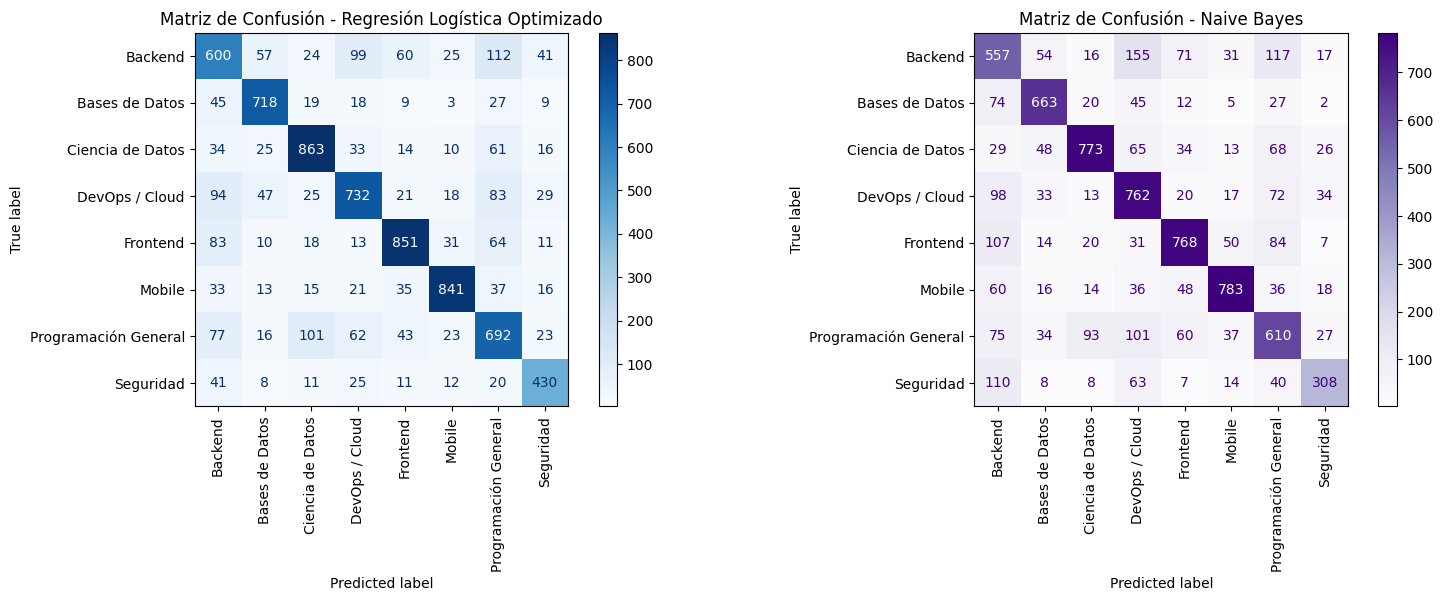

In [ ]:
# Matriz de Confusión Comparativa (Modelo Optimizado vs Naive Bayes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_estimator(
    mejor_modelo,
    X_test_tfidf,
    y_test,
    ax=axes[0],
    xticks_rotation='vertical',
    cmap='Blues',
)
axes[0].set_title('Matriz de Confusión - Regresión Logística Optimizado')

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test_tfidf,
    y_test,
    ax=axes[1],
    xticks_rotation='vertical',
    cmap='Purples',
)
axes[1].set_title('Matriz de Confusión - Naive Bayes')

plt.tight_layout()
plt.show()

In [ ]:
# Tabla Comparativa de Modelos
df_comparativa = pd.DataFrame([metricas_lr, metricas_nb, metricas_opt])
print('\n--- TABLA COMPARATIVA DE MODELOS ---')
print(df_comparativa)


--- TABLA COMPARATIVA DE MODELOS ---
                             Modelo  Accuracy  Precision    Recall        F1
0          Regresión Logística Base  0.747845   0.749054  0.747845  0.748144
1                       Naive Bayes  0.682162   0.690036  0.682162  0.684104
2  Regresión Logística (Optimizado)  0.747845   0.749054  0.747845  0.748144


In [ ]:
# Seleccionar y guardar el mejor modelo entrenado junto al vectorizador
joblib.dump(mejor_modelo, 'modelo_clasificacion.pkl')
joblib.dump(vector, 'vectorizador_tfidf.pkl')
print(
    '\n¡Modelo y vectorizador guardados exitosamente como archivos .pkl en el'
    ' directorio actual!'
)


¡Modelo y vectorizador guardados exitosamente como archivos .pkl en el directorio actual!
